In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/kaggle/input/datasets/yachna26/aqi-weather-mumbai/mumbai_final_dataset.csv")

In [3]:
df.head()

,time,us_aqi,pm2_5,pm10,nitrogen_dioxide,ozone,sulphur_dioxide,carbon_monoxide,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,wind_direction_10m,surface_pressure
0,2025-06-13T00:00,57,17.1,30.7,7.6,50.0,10.4,247.0,29.0,86,0.2,13.2,299,1001.5
1,2025-06-13T01:00,57,16.2,31.1,6.3,51.0,8.6,188.0,28.9,86,0.1,12.9,300,1000.7
2,2025-06-13T02:00,58,23.1,51.0,5.5,51.0,7.2,147.0,28.8,87,0.1,11.3,303,1000.6
3,2025-06-13T03:00,59,17.8,38.6,5.5,51.0,6.7,134.0,28.5,88,0.1,12.9,310,1000.1
4,2025-06-13T04:00,59,17.8,39.8,6.0,52.0,6.7,137.0,28.2,90,0.1,13.2,323,1000.3


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   time                  8784 non-null   object 
 1   us_aqi                8784 non-null   int64  
 2   pm2_5                 8784 non-null   float64
 3   pm10                  8784 non-null   float64
 4   nitrogen_dioxide      8784 non-null   float64
 5   ozone                 8784 non-null   float64
 6   sulphur_dioxide       8784 non-null   float64
 7   carbon_monoxide       8784 non-null   float64
 8   temperature_2m        8784 non-null   float64
 9   relative_humidity_2m  8784 non-null   int64  
 10  precipitation         8784 non-null   float64
 11  wind_speed_10m        8784 non-null   float64
 12  wind_direction_10m    8784 non-null   int64  
 13  surface_pressure      8784 non-null   float64
dtypes: float64(10), int64(3), object(1)
memory usage: 960.9+ KB


In [6]:
df.isnull().sum()

time                    0
us_aqi                  0
pm2_5                   0
pm10                    0
nitrogen_dioxide        0
ozone                   0
sulphur_dioxide         0
carbon_monoxide         0
temperature_2m          0
relative_humidity_2m    0
precipitation           0
wind_speed_10m          0
wind_direction_10m      0
surface_pressure        0
dtype: int64

In [7]:
df.describe()

,us_aqi,pm2_5,pm10,nitrogen_dioxide,ozone,sulphur_dioxide,carbon_monoxide,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,wind_direction_10m,surface_pressure
count,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000
mean,106.216530,35.588764,49.637250,16.436498,98.273338,22.732058,431.917919,27.348179,69.203893,0.281990,9.783538,216.719945,1008.485405
std,51.303656,23.092355,22.136388,10.985335,68.148252,13.196523,254.742213,3.335468,19.131668,1.036285,5.314040,105.280899,3.952363
min,36.000000,3.700000,3.800000,1.900000,10.000000,2.200000,103.000000,17.800000,11.000000,0.000000,0.000000,1.000000,994.800000
25%,65.000000,18.700000,34.200000,8.100000,51.000000,12.400000,225.000000,25.400000,56.000000,0.000000,5.700000,144.000000,1005.500000
50%,82.000000,26.400000,46.000000,13.000000,75.000000,20.700000,371.500000,27.000000,73.000000,0.000000,9.100000,246.000000,1008.400000
75%,150.000000,48.500000,61.500000,22.000000,117.250000,30.400000,566.250000,29.500000,85.000000,0.100000,13.100000,298.000000,1011.600000
max,297.000000,143.900000,145.800000,80.600000,523.000000,94.400000,1757.000000,39.800000,100.000000,17.800000,31.700000,360.000000,1018.200000


In [9]:
df.shape

(8784, 14)

In [10]:
df['time'] = pd.to_datetime(df['time'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   time                  8784 non-null   datetime64[ns]
 1   us_aqi                8784 non-null   int64         
 2   pm2_5                 8784 non-null   float64       
 3   pm10                  8784 non-null   float64       
 4   nitrogen_dioxide      8784 non-null   float64       
 5   ozone                 8784 non-null   float64       
 6   sulphur_dioxide       8784 non-null   float64       
 7   carbon_monoxide       8784 non-null   float64       
 8   temperature_2m        8784 non-null   float64       
 9   relative_humidity_2m  8784 non-null   int64         
 10  precipitation         8784 non-null   float64       
 11  wind_speed_10m        8784 non-null   float64       
 12  wind_direction_10m    8784 non-null   int64         
 13  surface_pressure  

In [11]:
df.duplicated().sum()

np.int64(0)

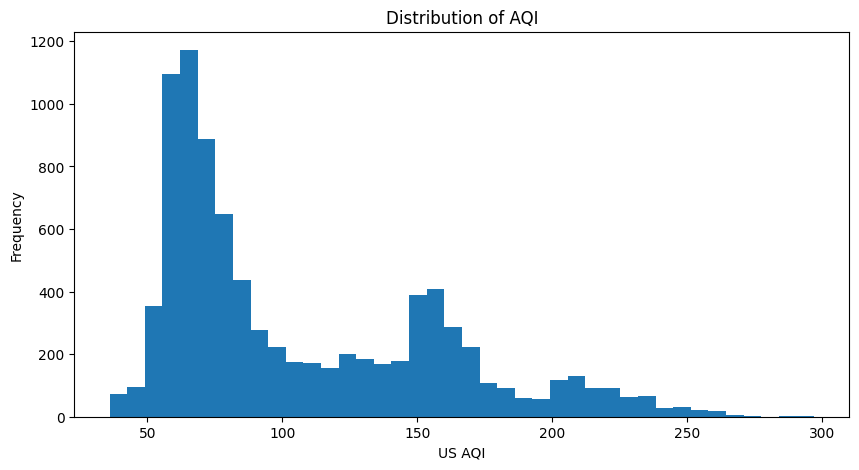

In [12]:
plt.figure(figsize=(10,5))
plt.hist(df['us_aqi'], bins=40)
plt.title("Distribution of AQI")
plt.xlabel("US AQI")
plt.ylabel("Frequency")
plt.show()

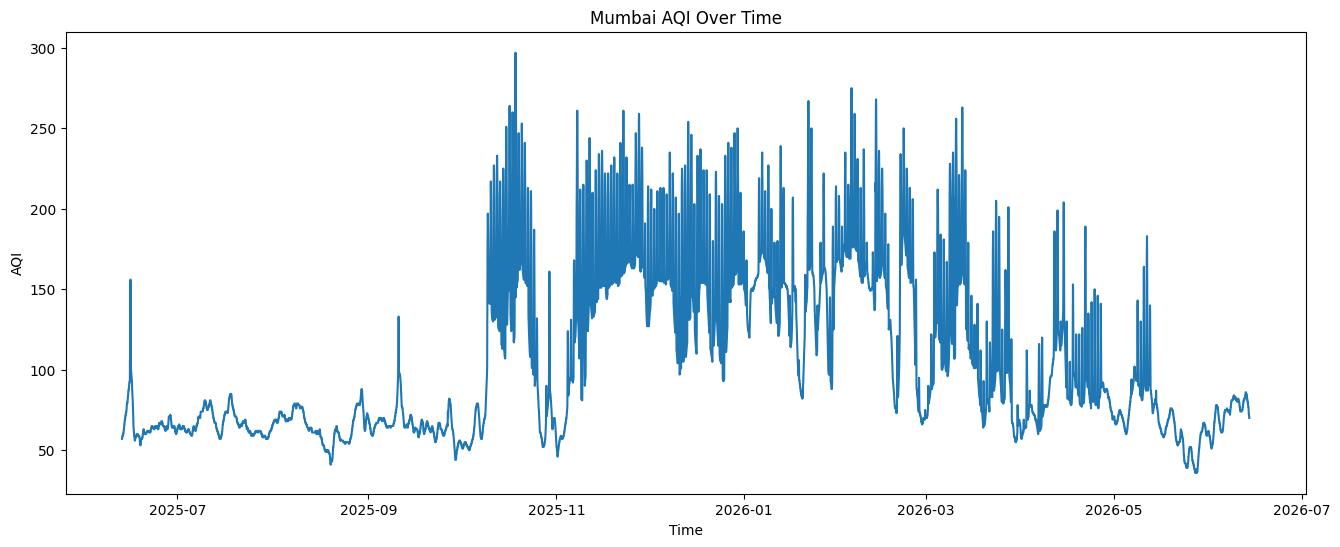

In [13]:
plt.figure(figsize=(16,6))
plt.plot(df['time'], df['us_aqi'])
plt.title("Mumbai AQI Over Time")
plt.xlabel("Time")
plt.ylabel("AQI")
plt.show()

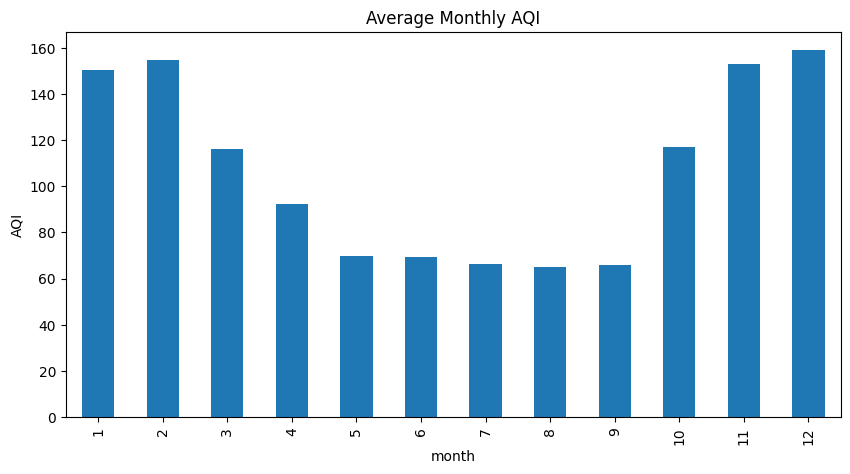

In [14]:
df['month'] = df['time'].dt.month
monthly_aqi = df.groupby('month')['us_aqi'].mean()
monthly_aqi.plot(kind='bar', figsize=(10,5))
plt.title("Average Monthly AQI")
plt.ylabel("AQI")
plt.show()

*Seasonal weather patterns strongly influence Mumbai's AQI dynamics* 

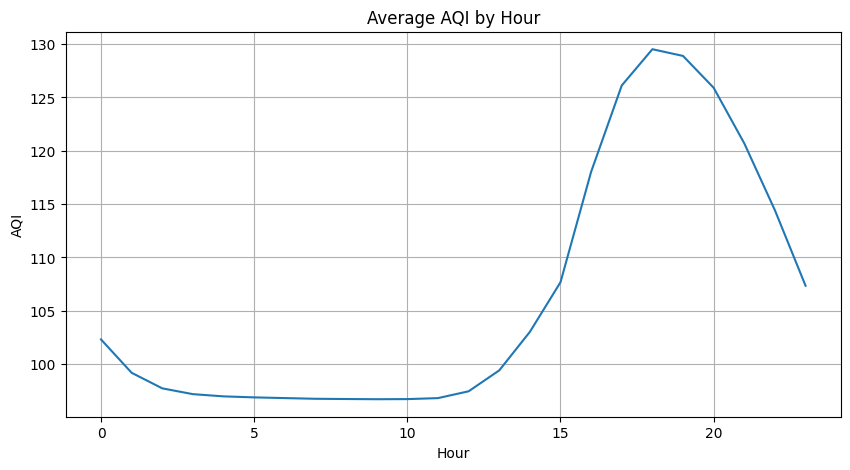

In [15]:
df['hour'] = df['time'].dt.hour
hourly_aqi = df.groupby('hour')['us_aqi'].mean()
hourly_aqi.plot(figsize=(10,5))
plt.title("Average AQI by Hour")
plt.xlabel("Hour")
plt.ylabel("AQI")
plt.grid()
plt.show()

In [16]:
corr = df.corr(numeric_only=True)
corr['us_aqi'].sort_values(ascending=False)

us_aqi                  1.000000
pm2_5                   0.799895
nitrogen_dioxide        0.662302
surface_pressure        0.581737
ozone                   0.577455
carbon_monoxide         0.571301
pm10                    0.547921
sulphur_dioxide         0.496781
hour                    0.169839
month                  -0.006445
temperature_2m         -0.055159
wind_direction_10m     -0.083734
precipitation          -0.216302
wind_speed_10m         -0.260663
relative_humidity_2m   -0.542193
Name: us_aqi, dtype: float64

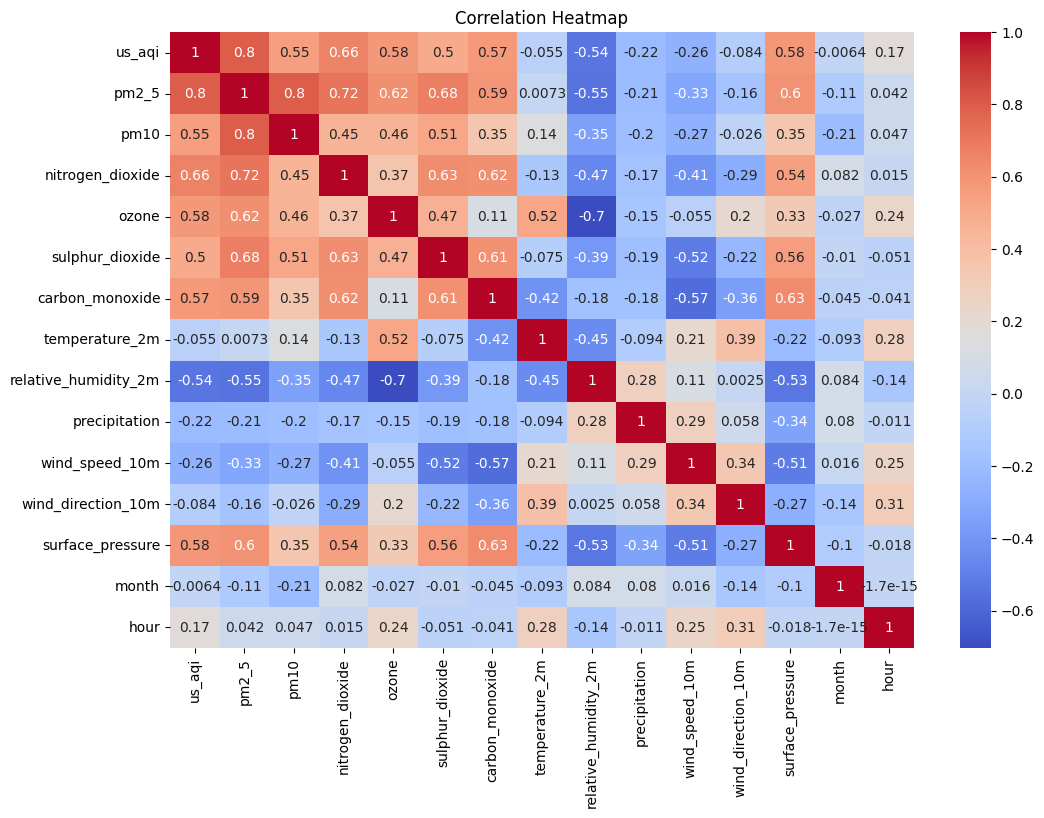

In [17]:
plt.figure(figsize=(12,8))
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()